# CSCI E-89 Assignment 03, Problem 5
## Single-prompt OpenAI Codex classifier

**Student:** Shyam (replace with full name before submission)

This notebook organizes the generated scripts into executable cells. The implementation follows the `Building an Image Classifier with PyTorch` section of `10_neural_nets_with_pytorch.ipynb`, with training-accuracy tracking added for this assignment.

## Source materials and generated-script map

The workspace source set reviewed for this deliverable includes the Chapter 10 notebook and HTML export, the linear-regression and logistic/MLP notebooks and HTML exports, and all five Lab 3 notebooks and HTML exports. The classifier below reuses the Chapter 10 data/model pattern and the Lab 3 environment and training-loop structure.

- Script 1: environment and reproducibility
- Script 2: Fashion-MNIST loading and data loaders
- Script 3: classifier definition
- Script 4: training with loss and accuracy history
- Script 5: evaluation, predictions, and plot

Problem 5 workflow: one longer OpenAI Codex request specified the full classifier, accuracy plot, notebook formatting, and validation requirements; this notebook is the integrated result.

### Step 1: Environment and reproducibility

This cell imports the required libraries, fixes random seeds, and selects the best available compute device for the single-prompt Codex workflow.

In [1]:
# Script 1: imports, device selection, and reproducibility.
from pathlib import Path
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.v2 as T

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print({'torch': torch.__version__, 'torchvision': torchvision.__version__, 'device': str(device)})

{'torch': '2.6.0', 'torchvision': '0.21.0', 'device': 'mps'}


### Step 2: Dataset and data loaders

This cell downloads Fashion-MNIST, prepares the image tensors, creates the data splits, and builds loaders for training, validation, and testing.

In [2]:
# Script 2: download Fashion-MNIST and create reproducible loaders.
from torch.utils.data import DataLoader

transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=(0.5,), std=(0.5,)),
])
data_root = Path('datasets')
train_valid = torchvision.datasets.FashionMNIST(
    data_root, train=True, download=True, transform=transform)
test_data = torchvision.datasets.FashionMNIST(
    data_root, train=False, download=True, transform=transform)
split_generator = torch.Generator().manual_seed(SEED)
train_data, valid_data = torch.utils.data.random_split(
    train_valid, [55_000, 5_000], generator=split_generator)
batch_size = 64
train_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(SEED))
valid_loader = DataLoader(valid_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
print(len(train_data), len(valid_data), len(test_data))

55000 5000 10000


### Step 3: Classifier definition

This cell creates the multilayer perceptron, selects cross-entropy loss, and configures the SGD optimizer.

In [3]:
# Script 3: define the MLP image classifier.
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, n_classes),
        )

    def forward(self, images):
        return self.mlp(images)

model = ImageClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

### Step 4: Training and history capture

This cell trains the model with a reusable epoch function and stores training and validation loss and accuracy for later analysis.

In [4]:
# Script 4: train while recording both loss and accuracy.
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.set_grad_enabled(training):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_correct += (logits.argmax(dim=1) == targets).sum().item()
            total_examples += targets.size(0)
    return total_loss / total_examples, total_correct / total_examples

history = {'train_loss': [], 'train_accuracy': [], 'valid_loss': [], 'valid_accuracy': []}
epochs = 5
for epoch in range(epochs):
    train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer)
    valid_loss, valid_accuracy = run_epoch(model, valid_loader, criterion)
    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['valid_loss'].append(valid_loss)
    history['valid_accuracy'].append(valid_accuracy)
    print(f'Epoch {epoch + 1}/{epochs}: train accuracy={train_accuracy:.3f}, validation accuracy={valid_accuracy:.3f}')

Epoch 1/5: train accuracy=0.820, validation accuracy=0.855


Epoch 2/5: train accuracy=0.861, validation accuracy=0.856


Epoch 3/5: train accuracy=0.876, validation accuracy=0.855


Epoch 4/5: train accuracy=0.885, validation accuracy=0.869


Epoch 5/5: train accuracy=0.892, validation accuracy=0.871


### Step 5: Evaluation and plot

This cell evaluates the trained classifier on held-out data, displays accuracy curves, and inspects several predicted labels.

Test loss=0.3641; test accuracy=0.867


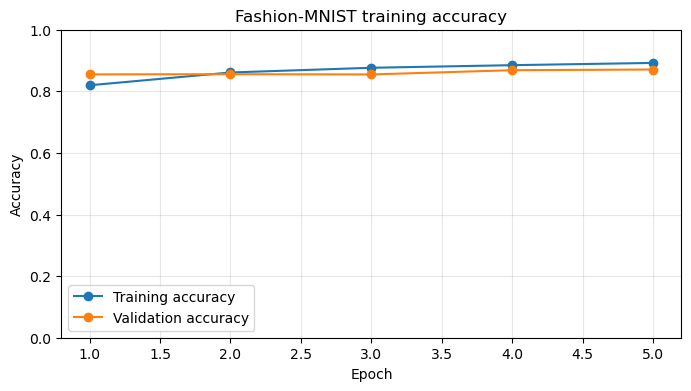

Predicted: [9, 2, 1, 1, 6, 1, 4, 6]
Actual:    [9, 2, 1, 1, 6, 1, 4, 6]


In [5]:
# Script 5: evaluate, inspect predictions, and plot training accuracy.
with torch.no_grad():
    test_loss, test_accuracy = run_epoch(model, test_loader, criterion)
print(f'Test loss={test_loss:.4f}; test accuracy={test_accuracy:.3f}')

plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs + 1), history['train_accuracy'], 'o-', label='Training accuracy')
plt.plot(range(1, epochs + 1), history['valid_accuracy'], 'o-', label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title('Fashion-MNIST training accuracy')
plt.show()

images, targets = next(iter(test_loader))
with torch.no_grad():
    predictions = model(images[:8].to(device)).argmax(dim=1).cpu()
print('Predicted:', predictions.tolist())
print('Actual:   ', targets[:8].tolist())

## Workflow record

The single-prompt Codex workflow requested the complete classifier notebook and then validated the generated cells and outputs. The first script established reproducibility and hardware selection. The second loaded and split Fashion-MNIST. The third implemented the MLP from the course notebook. The fourth added a reusable epoch function and recorded training and validation accuracy. The fifth evaluated the test set and generated the required accuracy plot. Each script was reviewed for executable ordering before being placed in this notebook.